# Question 1

In [2]:
from perceptron_torch_1 import model
import torch


# evaluate the weigts and bias
# do not adjust the gradients
with torch.no_grad():
    # retreve from layer 1
    weights = model.l1.weight[0].cpu().tolist()
    bias = model.l1.bias[0].item()


    for weight in weights:
        print(f"weight: {round(weight,4)}")
    print(f"bias: {round(bias,4)}")

weight: 0.4408
weight: 0.3403
weight: 0.8675
bias: 0.4159


The labels for “onehotnot” are determined by the first input bit x1. Therefore the model learns over time that the weights w1,w2  for the other two inputs need to have less impact since those inputs don't affect the output label. Therefore both weights w1, w2 converge to zero during training.


# Question 2

weight: 0.653
weight: 0.3281
weight: 0.6826
bias: 0.02


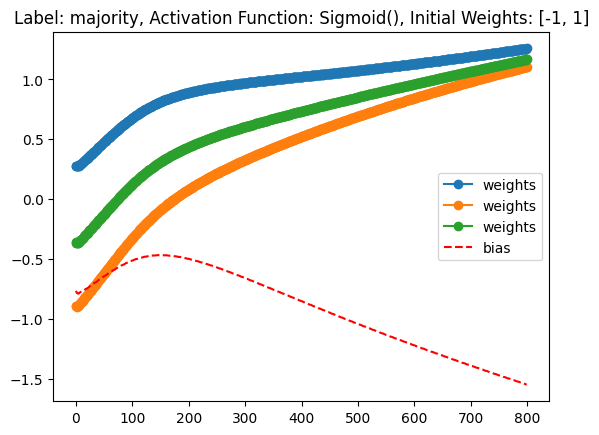

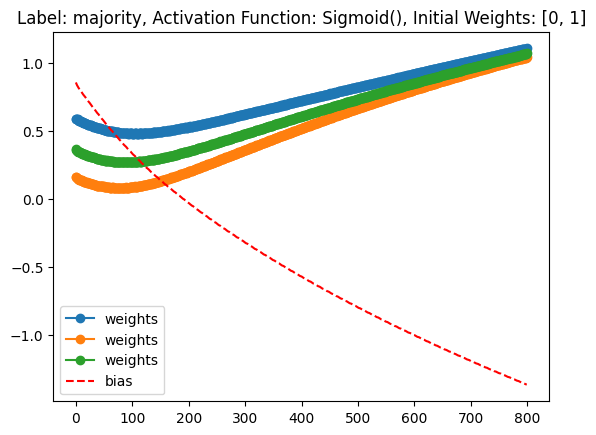

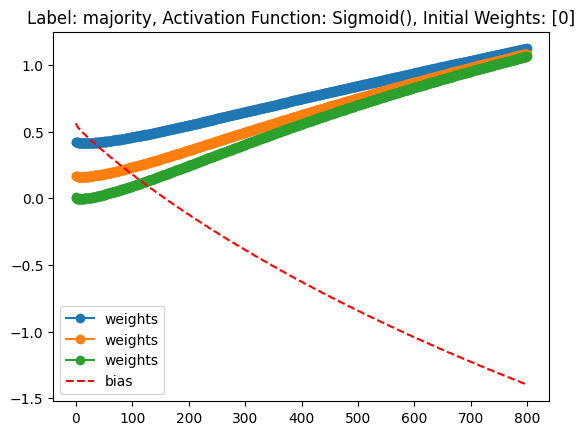

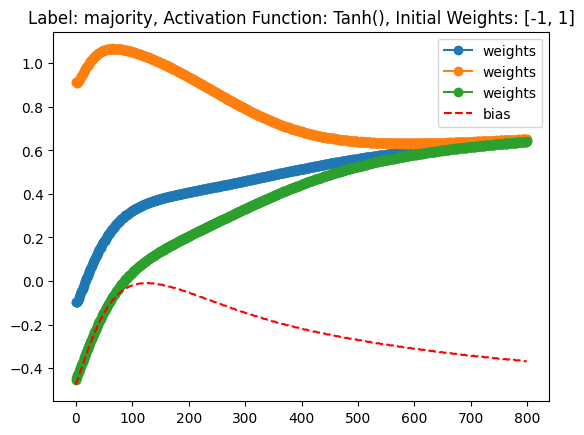

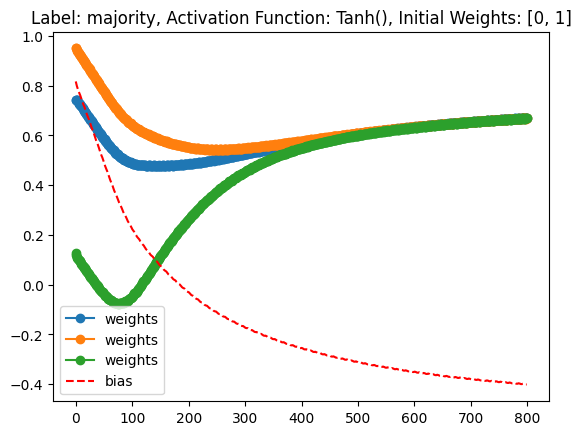

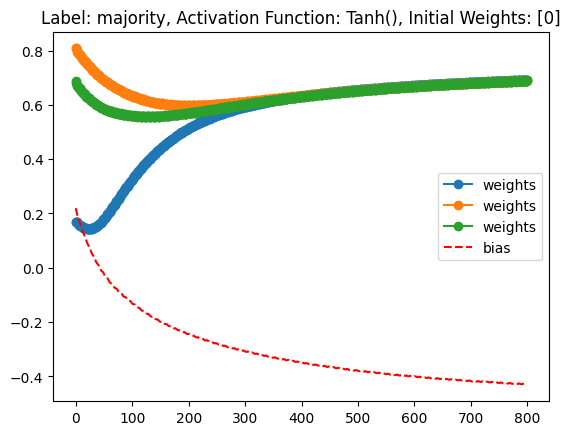

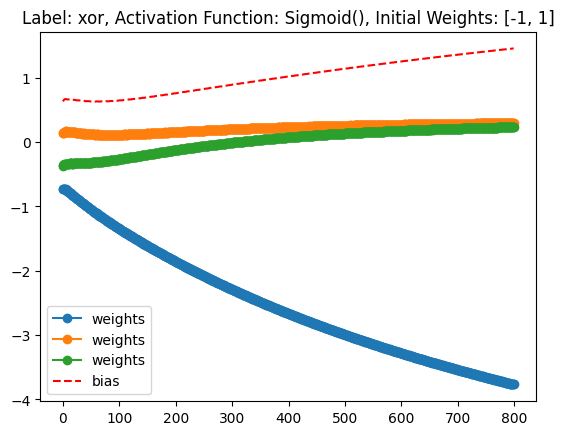

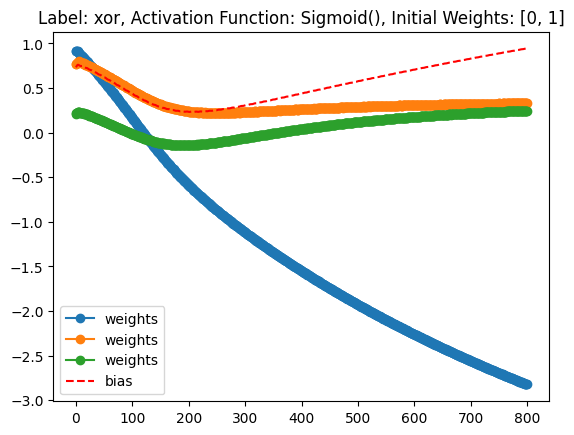

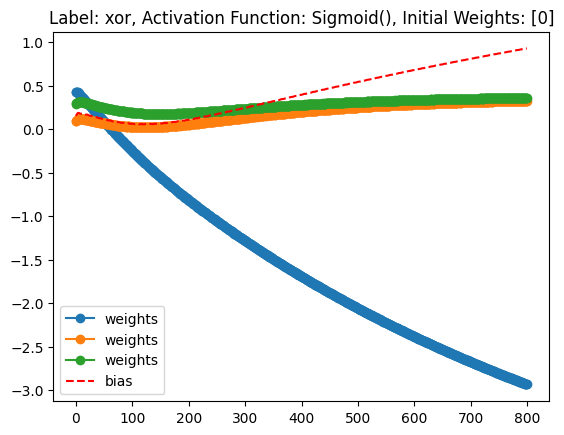

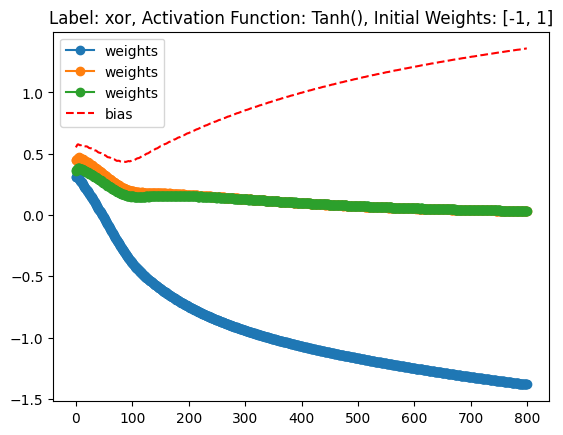

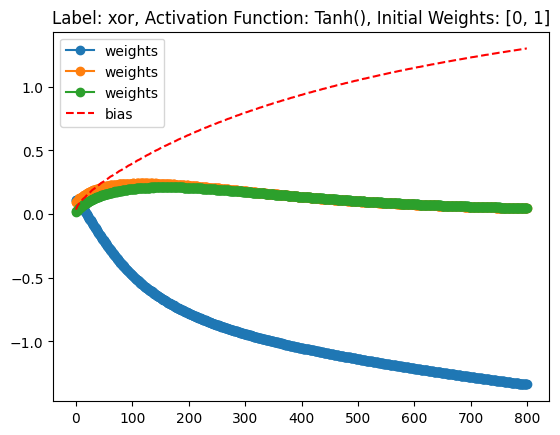

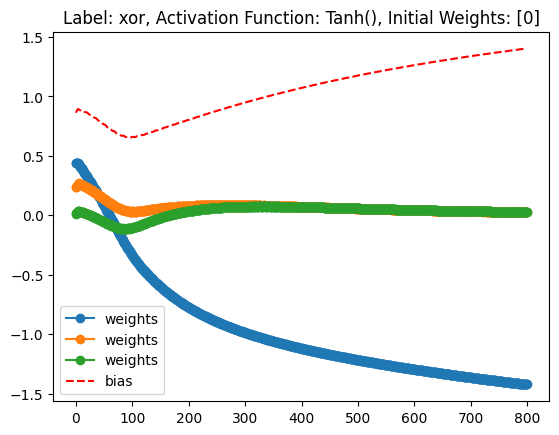

In [4]:
import perceptron_torch_1
from importlib import reload
reload(perceptron_torch_1)
perceptron_torch_1.non_batched_learning_evaluate()

Analyzing thew plots we can see that sigmoid taces longer to converge than the other 2 and using zero init takes faster to converge 

# Question 3

The weights from the result

| weight | Value |
| --- | ---: |
| a | 0 |
| b | 0 |
| c | 0 |
| d | 1 |
| e | -1 |
| f | 0 |
| g | -1 |
| h | 1 |
| i | 0 |
| j | -0.5 |
| k | 1 |
| l | 1 |
| m | 0 |

# Question 4

In [ ]:
import torch
import torch.nn as nn

# The network with 2 hidden layers:
class NeuralNet(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        nn.Module.__init__(self)
        self.l1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.l2 = nn.Linear(hidden_size, hidden_size)
        self.l3 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out = self.l1(x)
        out = self.relu(out)
        out = self.l2(out)
        out = self.relu(out)
        out = self.l3(out)
        return out


# Test result

original params (hidden_layers = 1, hidden_layer_size = 500):
acc = 97.04%

(hidden_layers = 1, hidden_layer_size = 200):
acc = 96.01%

(hidden_layers = 2, hidden_layer_size = 200):
acc = 94.6 %

(hidden_layers = 2, hidden_layer_size = 200):
acc = 96.7%

(hidden_layers = 2, hidden_layer_size = 300):
acc = 96.84%

(hidden_layers = 2, hidden_layer_size = 350):
acc = 97.2 %

## Result
After the study I found that when using 2 hidden layers the size of the layers should be somewhere between 300-350.

# Question 5

In [ ]:
# Adding a single perception network with no hidden layers:'
class Perceptron(nn.Module):
    def __init__(self, input_size, num_classes):
        nn.Module.__init__(self)
        self.l1 = nn.Linear(input_size, num_classes)

    def forward(self, x):
        out = self.l1(x)
        return out


## Test result
After removing the hidden layer the test result decreased to 91.47%

# Question 6

## Test result:

After training the baby-turtle model for around 1000 iterations pretraining and 200 STF iterations I get a loss on around 0.32 which proves that it works ok. The trining proces for this model were faster than big-turtle.

After trying the nano-trutle with over 1500 pretraining iterations and 300 STF we still got a loss function of over 1.300 and after testing to prompt we didnt get a single readable word from the model. 

Also, by installing cuda the training process went much faster when running on my gpu and that made it possible to run many iterations of the testing.

# Question 7

I ablated all normalization layers and changed GeLu activation function to Sigmoid:

In [ ]:
class NewGELU(nn.Module):
    def forward(self, x):
        return torch.sigmoid(x)
    

layer_norm_1 = nn.Identity()
layer_norm_2 = nn.Identity()

I ran the big-turtle model and it could run but the result of the training was much worse than before, while still taking vary long to train. I managed to get down to 0.9 after 500 iterations training and 120 iterations of STF

# Question 8
I ablated the residual connections by replacing the previouse forward method in the transform block class. I also send with a parameter that residual connections defults off.


In [ ]:
def forward(self, x):
        if self.use_residual:
            x = x + self.attn(self.layer_norm_1(x))
            x = x + self.feedforward(self.layer_norm_2(x))
        else:
            x = self.attn(self.layer_norm_1(x))
            x = self.feedforward(self.layer_norm_2(x))
        return x

I tested even this on a big-turtle model. After these changes it was even slower to train and i couldnbt get a better training loss than 1.2 and not lower than 1.0 when fine tuning.

# Question 9